In [678]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [679]:
## lets create synthetic data points
from sklearn.datasets import make_classification

In [680]:
X,y=make_classification(n_samples=1000,n_features=2,n_classes=2,n_clusters_per_class=1,n_redundant=0)

df=pd.DataFrame(X)

<Axes: xlabel='0', ylabel='1'>

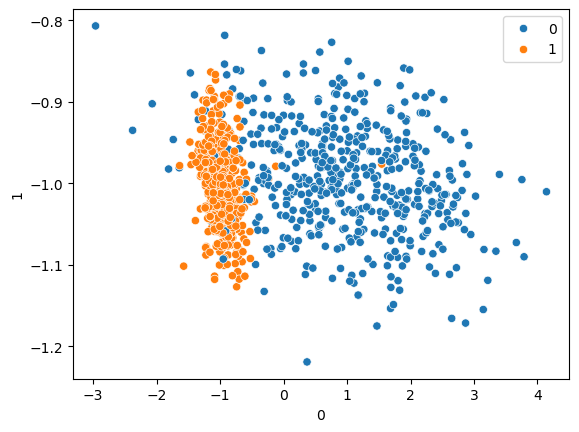

In [681]:
sns.scatterplot(x=pd.DataFrame(X)[0],y=pd.DataFrame(X)[1],hue=y,)

In [682]:
import plotly.express as pd

fig=pd.scatter_3d(df,x=X[:,1],y=y,z=X[:,1]*y)
fig.show()

In [683]:
df=sns.load_dataset("tips")

In [684]:
df.drop_duplicates(inplace=True)

<Axes: >

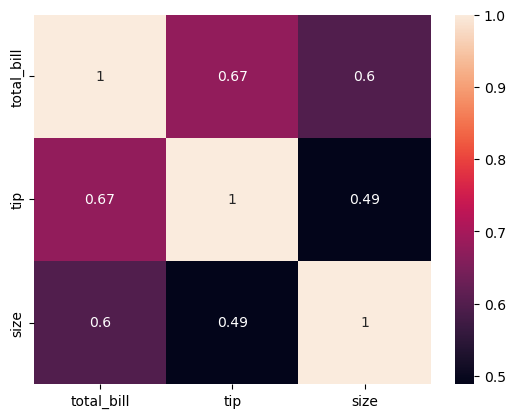

In [685]:
corr=df.corr(numeric_only=True)
sns.heatmap(corr,annot=True)

In [686]:
df.head(1)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2


In [687]:
from scipy.stats import f_oneway

groups = [g["total_bill"] for _, g in df.groupby("day")]

f, p = f_oneway(*groups)

print("day")
print("P-value:", p)

if p < 0.05:
    print("Significant relationship")
else:
    print("Not significant")

day
P-value: 0.049079098725077826
Significant relationship


In [688]:
from scipy.stats import f_oneway
import pandas as pd

target = "total_bill"

categorical_cols = ['sex', 'smoker','time']

for col in categorical_cols:
    groups = [g[target].dropna().values for _, g in df.groupby(col)]

    if len(groups) >= 2:
        f_stat, p = f_oneway(*groups)

        print(f"\nFeature: {col}")
        print(f"P-value: {p:.5f}")

        if p < 0.05:
            print("Reject H0 → Feature is significantly related to the target.")
        else:
            print("Fail to Reject H0 → Feature is not significantly related to the target.")


Feature: sex
P-value: 0.02759
Reject H0 → Feature is significantly related to the target.

Feature: smoker
P-value: 0.16131
Fail to Reject H0 → Feature is not significantly related to the target.

Feature: time
P-value: 0.00507
Reject H0 → Feature is significantly related to the target.


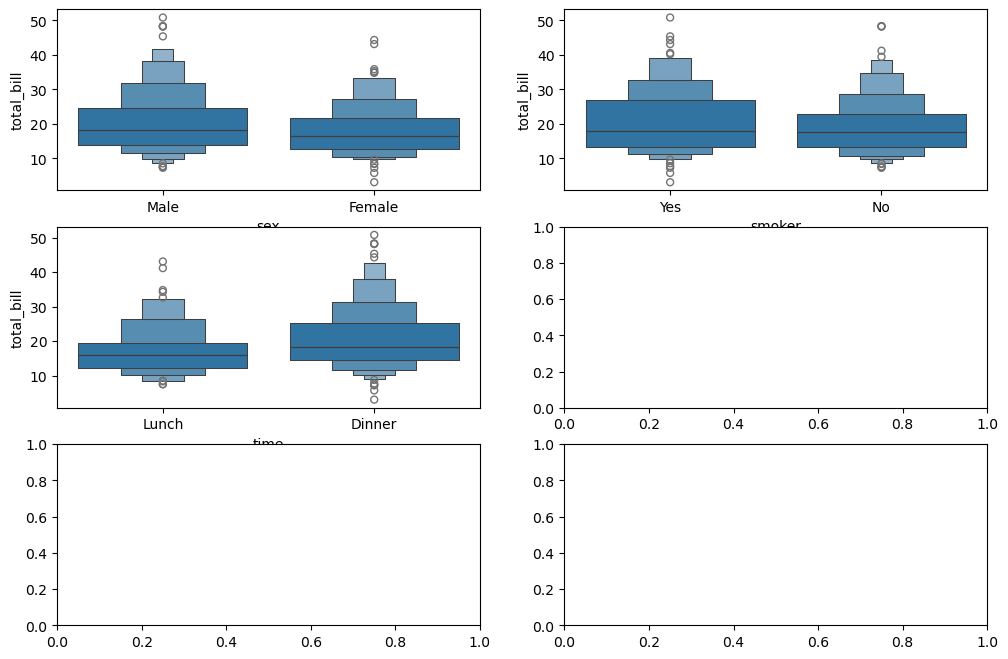

In [689]:
fig,ax=plt.subplots(3,2,figsize=(12,8))

for i,col in enumerate(categorical_cols):
    sns.boxenplot(data=df,x=col,y="total_bill",ax=ax[i//2,i%2])

<Axes: xlabel='total_bill', ylabel='Count'>

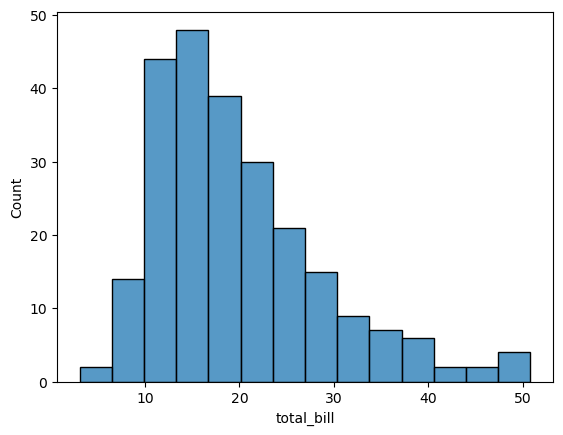

In [690]:
sns.histplot(data=df,x="total_bill")

In [691]:
from sklearn.model_selection import train_test_split

X=df.drop("total_bill",axis=1)
y=df["total_bill"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [692]:
X_train

,tip,sex,smoker,day,time,size
227,3.00,Male,No,Sat,Dinner,4
65,3.15,Male,No,Sat,Dinner,3
168,1.61,Female,Yes,Sat,Dinner,2
207,3.00,Male,Yes,Sat,Dinner,4
144,2.30,Female,No,Thur,Lunch,2
...,...,...,...,...,...,...
106,4.06,Male,Yes,Sat,Dinner,2
14,3.02,Female,No,Sun,Dinner,2
92,1.00,Female,Yes,Fri,Dinner,2
179,3.55,Male,Yes,Sun,Dinner,2


In [693]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
transformer=ColumnTransformer([
    ("onehotencoding",OneHotEncoder(drop="first",dtype="int",handle_unknown="ignore"),["sex","smoker","day","time"]),
    ("scaler",StandardScaler(),["tip","size"])
],remainder="passthrough")


In [694]:
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

pipeline=Pipeline([
    ("ct",transformer),
    ("model",SVR())
])

pipeline.fit(X_train,y_train)

y_pred=pipeline.predict(X_test)

print(r2_score(y_test,y_pred))



0.35331259951355465


In [695]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__C": [0.1, 1, 10, 100],
    "model__kernel": ["linear", "rbf"],
    "model__gamma": ["scale", "auto", 0.01, 0.1],
    "model__epsilon": [0.01, 0.1, 0.2]
}

grid=GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring="accuracy"
)

grid.fit(X_train,y_train)

print(grid.best_score_)
best_model=grid.best_estimator_

y_pred=best_model.predict(X_test)

print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))

nan
0.5094154196505856
4.1772391273219025
34.974245727206934


In [696]:
grid.best_params_

{'model__C': 0.1,
 'model__epsilon': 0.01,
 'model__gamma': 'scale',
 'model__kernel': 'linear'}